# **Adult Dataset Assignment**

# Importing Libraries & Loading the Dataset

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [50]:
df = pd.read_csv("adult.csv")

# Exploring The Dataset

In [3]:
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


# Renaming fngwgt to final-weight

In [24]:
df = df.rename(columns={"fnlwgt" : "final-weight"})

# Types of workclass

In [11]:
df.workclass.unique()

array(['Private', 'Local-gov', '?', 'Self-emp-not-inc', 'Federal-gov',
       'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [13]:
df.workclass.value_counts()

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
?                    2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

# Dropping duplicate values

In [31]:
df.duplicated().sum()

np.int64(52)

In [51]:
df.drop_duplicates(inplace=True)

In [70]:
df.income.unique()

array(['<=50K', '>50K'], dtype=object)

# Statistical summary of the data

In [71]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48790.000000,4.879000e+04,48790.000000,48790.000000,48790.000000,48790.000000
mean,38.652798,1.896690e+05,10.078807,1080.217688,87.595573,40.425886
std,13.708493,1.056172e+05,2.570046,7455.905921,403.209129,12.392729
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781385e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376062e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


# Differentiate income with 0 & 1 Values

In [73]:
df['income_bin'] = (df['income'] == '>50K').astype(int)

In [78]:
df.tail(2)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,income_bin
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K,0
48841,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K,1


# Dropping Useless Columns

In [81]:
df.drop(columns="educational-num",inplace=True)

In [86]:
df.head(15)

,age,workclass,fnlwgt,education,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,income_bin
0,25,Private,226802,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0
1,38,Private,89814,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0
2,28,Local-gov,336951,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,1
3,44,Private,160323,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,1
4,18,?,103497,Some-college,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K,0
5,34,Private,198693,10th,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K,0
6,29,?,227026,HS-grad,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K,0
7,63,Self-emp-not-inc,104626,Prof-school,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K,1
8,24,Private,369667,Some-college,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K,0
9,55,Private,104996,7th-8th,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K,0


# Replacing "?" with np.nan

In [87]:
df = df.replace('?', np.nan)

In [88]:
df.head(15)

,age,workclass,fnlwgt,education,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,income_bin
0,25,Private,226802,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,0
1,38,Private,89814,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,0
2,28,Local-gov,336951,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,1
3,44,Private,160323,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,1
4,18,NaN,103497,Some-college,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K,0
5,34,Private,198693,10th,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K,0
6,29,NaN,227026,HS-grad,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,<=50K,0
7,63,Self-emp-not-inc,104626,Prof-school,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K,1
8,24,Private,369667,Some-college,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K,0
9,55,Private,104996,7th-8th,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K,0


# Plotting income relation with education

In [95]:
rate = df.groupby('education')['income_bin'].mean().sort_values(ascending=False)
rate

education
Prof-school     0.739808
Doctorate       0.725589
Masters         0.549322
Bachelors       0.413204
Assoc-acdm      0.257964
Assoc-voc       0.253398
Some-college    0.189727
HS-grad         0.158592
12th            0.073282
7th-8th         0.064990
10th            0.062635
9th             0.054233
5th-6th         0.053254
11th            0.050773
1st-4th         0.032653
Preschool       0.012346
Name: income_bin, dtype: float64

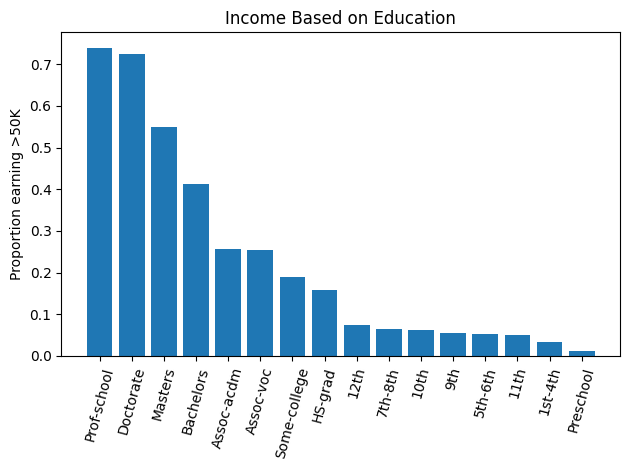

In [98]:
plt.bar(rate.index, rate.values)
plt.title("Income Based on Education")
plt.xticks(rotation=75)
plt.ylabel('Proportion earning >50K')
plt.tight_layout()
plt.show()


# Plotting income relation with workclass

In [100]:
rate = df.groupby('workclass')['income_bin'].mean().sort_values(ascending=False)
rate

workclass
Self-emp-inc        0.553719
Federal-gov         0.391760
Local-gov           0.295599
Self-emp-not-inc    0.278943
State-gov           0.267542
Private             0.217986
Without-pay         0.095238
Never-worked        0.000000
Name: income_bin, dtype: float64

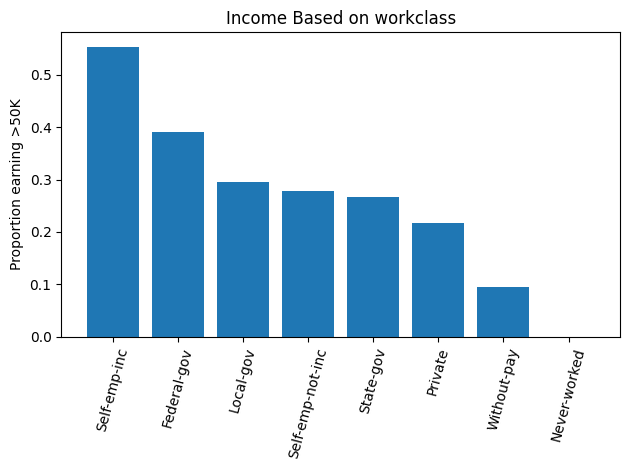

In [102]:
plt.bar(rate.index, rate.values)
plt.title("Income Based on workclass")
plt.xticks(rotation=75)
plt.ylabel('Proportion earning >50K')
plt.tight_layout()
plt.show()


# Saving the Preprocessed dataset

In [103]:
df.to_csv("cleaned_adult.csv")